# Task 3: Auditing `audit_a_realiser.py`

**Goal.** Find the errors, fix them (`analysis/audit_corrected.py`), and measure what each one changes in the
recommendation. Errors are ranked by consequence.

| Rank | Error                                                               | Fix                     | Consequence on the decision       |
| ---- | ------------------------------------------------------------------- | ----------------------- | --------------------------------- |
| 1    | Recommends the lowest P90, ignoring fires and cost                  | Read the trade-offs     | **Reverses it**                   |
| 2    | Pareto test counts more vehicles as better                          | Minimise all objectives | Hides every plan under 8 vehicles |
| 3    | One replay per plan on a noisy simulator                            | 5 replays               | Results off by up to 37 fires     |
| 4    | Drops calls with no arrival, counts vehicle rows, `percentile(0.9)` | Business guide rules    | None, but P90 printed as 2.1 min  |


In [ ]:
import pandas as pd
import helpers as h
import figures as fg
import simulation as sim
import audit_corrected as audit

raw = h.load_raw()
plans = audit.sample_configurations(
    raw["centres"]["code_cis"].tolist()
)  # the audit's 40 plans, same seed
n1 = audit.evaluate_all(plans, 1, "E_audit_n1")  # as the audit ran them
n5 = audit.evaluate_all(plans, 5, "E_audit_n5")  # corrected: mean of 5 replays

## 1. Data errors: the printed P90


In [2]:
audit.p90_steps(raw).to_frame("SAP P90 (min)")

,SAP P90 (min)
"Original: rows, unfulfilled dropped, percentile(0.9)",2.10
+ fix percentile (90),32.12
"+ fix one value per call, first arrival",24.73
+ fix unfulfilled kept at 60 min (official rule),25.51


The script prints 2.1 min instead of 25.51. Only printed: the plans are scored by the simulator, so the decision
does not change.


## 2. Decision errors: one fix at a time


In [ ]:
runs = sim.load_runs()
task2 = runs[runs["tag"] == "E_joint"].assign(
    label=lambda d: d["vehicles"].map({2: "A", 4: "B", 8: "C", 12: "D"})
)
front_1 = audit.front_original(n1)


def step(df, front):
    pick = (
        df[front].sort_values("p90").index[0]
    )  # the audit's rule: lowest P90 on the front
    return {
        "plans on the front": int(front.sum()),
        "pick": f"plan {pick}",
        "vehicles": int(df.loc[pick, "cost"]),
        "P90 (min)": round(df.loc[pick, "p90"], 2),
        "unanswered fires": round(df.loc[pick, "inc"]),
    }


d = task2.set_index("label").loc["D"]
pd.DataFrame(
    {
        "audit as written": step(n1, front_1),
        "+ all objectives minimised": step(n1, audit.front_corrected(n1)),
        "+ 5 replays": step(n5, audit.front_corrected(n5)),
        "for reference: Task 2, plan D": {
            "pick": "plan D",
            "vehicles": 12,
            "P90 (min)": round(d["p90"], 2),
            "unanswered fires": round(d["inc"]),
        },
    }
).T.fillna("")

,plans on the front,pick,vehicles,P90 (min),unanswered fires
audit as written,8,plan 14,12,22.64,168
+ all objectives minimised,19,plan 14,12,22.64,168
+ 5 replays,22,plan 14,12,22.84,192
"for reference: Task 2, plan D",,plan D,12,21.96,19


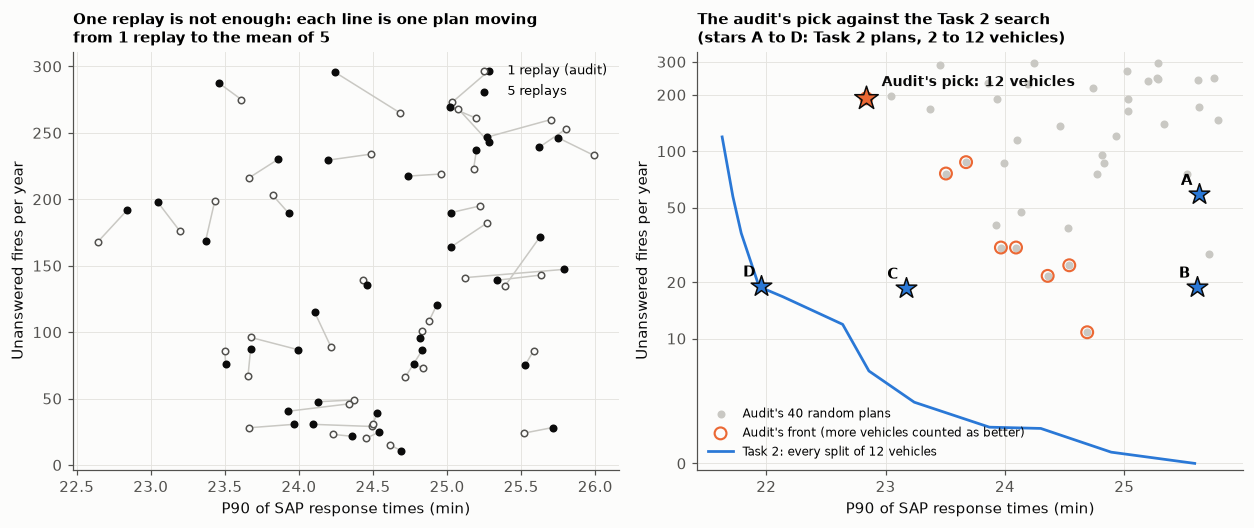

In [ ]:
fg.audit_comparison(
    n1, n5, front_1, 14, pd.read_csv(h.RESULTS / "pareto_front.csv"), task2
)

- **Lowest P90 wins:** it picks 12 vehicles that still leave 192 fires unanswered. Plan 30 on the same list uses
  2 vehicles and leaves 120. Task 2's 12 vehicles leave 19.
- **More vehicles = better:** the front drops from 19 plans to 8. Same pick, but no cheap option is shown.
- **One replay:** same pick here, but its fires read 168 instead of 192.


In [ ]:
used = runs[runs["tag"].str.startswith("E_audit")]["n"].sum()
print(
    f"Task 3: {used} replays, plus 5 charged by an interrupted run and not logged. {sim.budget_left()} of 2000 left."
)

Task 3: 240 replays, plus 5 charged by an interrupted run and not logged. 805 of 2000 left.
